# War Events (Air Alarms) — Exploratory Data Analysis

This Jupyter Notebook presents an analysis of air alarm data collected across Ukrainian regions during the full-scale war period (February 24, 2022 — March 16, 2026). We test the  distribution of alarms, identify patterns in alarm intensity and duration, generate features for further modeling, and explore how alarm activity developed over the course of the war.

**Files used:** `alarms-merged.csv`, `regions.csv`



---
## Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
%pip install scikit-learn
from typing import Optional
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator
from sklearn.preprocessing import LabelEncoder



warnings.filterwarnings('ignore')

MY_PALETTE = {
    'main_red':    '#FB5607',
    'accent_blue': '#3A86FF',
    'mid_navy':    '#FFBE0B',
    'light_blue':  '#8338EC',
    'cream':       '#FF006E'
}
MY_COLOR_LIST = ['#FF006E', '#FB5607', '#FFBE0B', '#8338EC', '#3A86FF']

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
sns.set_palette(sns.color_palette(MY_COLOR_LIST))
print('Setup complete')

Note: you may need to restart the kernel to use updated packages.
Setup complete


---
## 1. Overview: Dataset Shape, Timeframe, Basic Info

In [2]:

df_alarms  = pd.read_csv('alarms-merged.csv', sep=';')
df_alarms  = df_alarms.drop(columns=['merged_id', 'region_title', 'original_alarms'])
df_regions = pd.read_csv('regions.csv')

print(f'alarms:  {df_alarms.shape[0]:,} rows x {df_alarms.shape[1]} columns')
print(f'regions: {df_regions.shape[0]} rows x {df_regions.shape[1]} columns')
print()
print('Alarms columns: ', df_alarms.columns.tolist())
print('Regions columns:', df_regions.columns.tolist())
df_alarms.head()

alarms:  76,232 rows x 6 columns
regions: 25 rows x 5 columns

Alarms columns:  ['id', 'region_id', 'region_city', 'all_region', 'start', 'end']
Regions columns: ['region', 'center_city_ua', 'center_city_en', 'region_alt', 'region_id']


,id,region_id,region_city,all_region,start,end
0,35427,12,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28
1,71822,23,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43
2,1746,3,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42
3,55540,19,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47
4,54611,18,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19


In [3]:
df_regions

,region,center_city_ua,center_city_en,region_alt,region_id
0,АР Крим,Сімферополь,Simferopol,Крим,1
1,Вінницька,Вінниця,Vinnytsia,Вінниччина,2
2,Волинська,Луцьк,Lutsk,Волинь,3
3,Дніпропетровська,Дніпро,Dnipro,Дніпропетровщина,4
4,Донецька,Донецьк,Donetsk,Донеччина,5
5,Житомирська,Житомир,Zhytomyr,Житомирщина,6
6,Закарпатська,Ужгород,Uzhgorod,Закарпаття,7
7,Запорізька,Запоріжжя,Zaporozhye,Запоріжжя,8
8,Івано-Франківська,Івано-Франківськ,Ivano-Frankivsk,Івано-Франківщина,9
9,Київська,Київ,Kyiv,Київщина,10


### 1.1 What is the total number of alarm records in the dataset?

In [4]:
rows, columns = df_alarms.shape
print(f'Dataset has {rows:,} rows and {columns} columns')

Dataset has 76,232 rows and 6 columns


### 1.2 What is the timeframe covered by the dataset?

In [5]:
# Convert to datetime first to check the range
start_col = pd.to_datetime(df_alarms['start'], errors='coerce')
end_col   = pd.to_datetime(df_alarms['end'],   errors='coerce')
print('Timeframe:', start_col.min(), 'to', end_col.max())
print(f'Total days covered: {(start_col.max() - end_col.min()).days}')

Timeframe: 2022-02-24 07:43:17 to 2026-03-17 07:26:30
Total days covered: 1481


### 1.3 What is the total number of unique regions in the dataset?

In [6]:
total_unique_regions = df_alarms['region_id'].nunique()
print(f'Number of unique region IDs in alarms: {total_unique_regions}')
print(f'Number of regions in regions table:    {df_regions.shape[0]}')

Number of unique region IDs in alarms: 23
Number of regions in regions table:    25


### 1.4 General info and data types

In [7]:
print('df_alarms.info()')
df_alarms.info()

df_alarms.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76232 entries, 0 to 76231
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           76232 non-null  int64 
 1   region_id    76232 non-null  int64 
 2   region_city  76232 non-null  object
 3   all_region   76232 non-null  int64 
 4   start        76232 non-null  object
 5   end          76232 non-null  object
dtypes: int64(3), object(3)
memory usage: 3.5+ MB


In [8]:
print(' Descriptive statistics')
df_alarms.describe(include='all') 

 Descriptive statistics


,id,region_id,region_city,all_region,start,end
count,76232.000000,76232.000000,76232,76232.000000,76232,76232
unique,NaN,NaN,24,NaN,74513,74315
top,NaN,NaN,Харківська обл.,NaN,2024-03-06 08:43:22,2025-10-14 11:50:49
freq,NaN,NaN,7807,NaN,5,5
mean,38138.351611,12.477359,NaN,0.972820,NaN,NaN
std,22026.175622,6.446595,NaN,0.162609,NaN,NaN
min,1.000000,1.000000,NaN,0.000000,NaN,NaN
25%,19063.750000,7.000000,NaN,1.000000,NaN,NaN
50%,38129.500000,13.000000,NaN,1.000000,NaN,NaN
75%,57210.250000,19.000000,NaN,1.000000,NaN,NaN


`describe(include=‘all’)` provides complete statistics for all columns.


---
## 2. Data Cleaning

### 2.1 Are there missing values (NaN)?

In [9]:
missing = df_alarms.isnull().sum()
missing_pct = (missing / len(df_alarms) * 100).round(2)
missing_df = pd.DataFrame({'NaN count': missing, '% of total': missing_pct})
print('Missing values per column:')
print(missing_df)

has_missing = missing_df[missing_df['NaN count'] > 0]
if has_missing.empty:
    print('\nNo missing values found!')
else:
    print(f'\n Missing values detected:')
    print(has_missing)
    fig, ax = plt.subplots(figsize=(8, 3))
    has_missing['% of total'].plot(kind='barh', ax=ax, color=MY_PALETTE['main_red'])
    ax.set_title('Share of Missing Values (NaN) per Column')
    ax.set_xlabel('% of missing values out of total rows')
    ax.set_ylabel('Column')
    plt.tight_layout()
    plt.show()

Missing values per column:
             NaN count  % of total
id                   0         0.0
region_id            0         0.0
region_city          0         0.0
all_region           0         0.0
start                0         0.0
end                  0         0.0

No missing values found!


### 2.2 Are there duplicate rows?

In [10]:
n_dupes     = df_alarms.duplicated().sum()
n_dupes_key = df_alarms.duplicated(subset=['region_id', 'start']).sum()
print(f'Full duplicate rows:                   {n_dupes}')
print(f'Duplicates by key (region_id, start):  {n_dupes_key}')

Full duplicate rows:                   0
Duplicates by key (region_id, start):  2


2 key duplicates based on `(region_id, start)` we remove them in section 2.4.

### 2.3 Are the date columns stored correctly as datetime?

In [11]:
print('Current data types:')
print(df_alarms.dtypes)
print()
print('Sample start value:', df_alarms['start'].iloc[0], '-> type:', type(df_alarms['start'].iloc[0]))
print('Expected after conversion: datetime64')

Current data types:
id              int64
region_id       int64
region_city    object
all_region      int64
start          object
end            object
dtype: object

Sample start value: 2022-02-24 07:43:17 -> type: <class 'str'>
Expected after conversion: datetime64


We explicitly demonstrate that `start` and `end` are plain strings — not datetime objects. 

In [12]:
df_alarms['region_city'].unique()

array(['Львівська обл.', 'Чернігівська обл.', 'Вінницька обл.',
       'Харківська обл.', 'Тернопільська обл.', 'Київ', 'Рівненська обл.',
       'Черкаська обл.', 'Одеська обл.', 'Запорізька обл.',
       'Волинська обл.', 'Житомирська обл.', 'Херсонська обл.',
       'Миколаївська обл.', 'Хмельницька обл.', 'Івано-Франківська обл.',
       'Дніпропетровська обл.', 'Кіровоградська обл.', 'Чернівецька обл.',
       'Полтавська обл.', 'Київська обл.', 'Сумська обл.',
       'Донецька обл.', 'Закарпатська обл.'], dtype=object)

 We show all unique values in `region_city` to understand the naming format.


### 2.4 Cleaning df — applying all fixes we discovered before

Convertation to datetime and then to UTC

In [13]:
df = df_alarms.copy()
print(f'Shape before cleaning: {df.shape}')

# Datetime
for col in ['start', 'end']:
    df[col] = pd.to_datetime(df[col], errors='coerce')


for col in ['start','end']:
    df[col] = (
        df[col]
        .dt.tz_localize('Europe/Kyiv', nonexistent='shift_forward', ambiguous='NaT')
        .dt.tz_convert('UTC')
    )

print("Timezone converted to UTC")
df.head()

Shape before cleaning: (76232, 6)
Timezone converted to UTC


,id,region_id,region_city,all_region,start,end
0,35427,12,Львівська обл.,1,2022-02-24 05:43:17+00:00,2022-02-24 07:52:28+00:00
1,71822,23,Чернігівська обл.,1,2022-02-24 12:00:43+00:00,2022-02-24 15:11:43+00:00
2,1746,3,Вінницька обл.,1,2022-02-24 13:40:42+00:00,2022-02-24 14:10:42+00:00
3,55540,19,Харківська обл.,1,2022-02-24 18:11:47+00:00,2022-02-24 18:59:47+00:00
4,54611,18,Тернопільська обл.,1,2022-02-24 23:59:36+00:00,2022-02-25 07:00:19+00:00


Convertation of `start`/`end` to datetime and immediately convert them from Kyiv time to UTC to align with other datasets.

In [14]:
before = len(df)
df = df.drop_duplicates(subset=['region_id', 'start'])
print(f'Duplicates removed: {before - len(df)}')


Duplicates removed: 5


Removing 5 key duplicates where same region had two alarms with identical start time

In [15]:
before = len(df)
df = df.dropna(subset=['region_id', 'start', 'end'])
print(f'Rows without region_id, start or end removed: {before - len(df)}')

Rows without region_id, start or end removed: 25


Removing 25 rows where `pd.to_datetime()` returned `NaT`—unparsed dates from the original source (~0.03% of the dataset).

In [16]:
# Remove logical anomalies: end < start
df['duration_hours'] = (df['end'] - df['start']).dt.total_seconds() / 3600
negative = (df['duration_hours'] < 0).sum()
print(f'Rows with end < start (anomaly): {negative}')
if negative > 0:
    before = len(df)
    df = df[df['duration_hours'] >= 0]
    print(f'Removed {before - len(df)} rows with negative duration')

Rows with end < start (anomaly): 1
Removed 1 rows with negative duration


Checking for logical anomalies where `end < start`; at the same time, we calculate `duration_hours` as a byproduct of this check.

In [17]:
df['region_name_clean'] = df['region_city'].str.replace(' обл.', '', regex=False).str.strip()

df.loc[df['region_name_clean'] == 'Київ', 'region_name_clean'] = 'Київська'
df.loc[df['region_name_clean'] == 'Крим', 'region_name_clean'] = 'АР Крим'

df = df.merge(
    df_regions[['region', 'center_city_en']], 
    left_on='region_name_clean', 
    right_on='region', 
    how='left'
)

df['region'] = df['center_city_en']
df['region'] = df['region'].replace('Zaporozhye', 'Zaporizhzhia')
df['region'] = df['region'].replace('Uzhgorod', 'Uzhhorod')


cols_to_drop = ['region_city', 'region_name_clean', 'center_city_en', 'region_x', 'region_y']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("Great success! English regions:")
print(df['region'].unique())

Great success! English regions:
['Lviv' 'Chernihiv' 'Vinnytsia' 'Kharkiv' 'Ternopil' 'Kyiv' 'Rivne'
 'Cherkasy' 'Odesa' 'Zaporizhzhia' 'Lutsk' 'Zhytomyr' 'Kherson' 'Mykolaiv'
 'Khmelnytskyi' 'Ivano-Frankivsk' 'Dnipro' 'Kropyvnytskyi' 'Chernivtsi'
 'Poltava' 'Sumy' 'Donetsk' 'Uzhhorod']


Cleaning the region names and merging them with `df_regions` to reach the standardized English names in the `region` column.

In [18]:
df.head()

,id,region_id,all_region,start,end,duration_hours,region
0,35427,12,1,2022-02-24 05:43:17+00:00,2022-02-24 07:52:28+00:00,2.153056,Lviv
1,71822,23,1,2022-02-24 12:00:43+00:00,2022-02-24 15:11:43+00:00,3.183333,Chernihiv
2,1746,3,1,2022-02-24 13:40:42+00:00,2022-02-24 14:10:42+00:00,0.500000,Vinnytsia
3,55540,19,1,2022-02-24 18:11:47+00:00,2022-02-24 18:59:47+00:00,0.800000,Kharkiv
4,54611,18,1,2022-02-24 23:59:36+00:00,2022-02-25 07:00:19+00:00,7.011944,Ternopil


In [19]:
print(f'  Rows before cleaning:  {df_alarms.shape[0]:>10,}')
print(f'  Rows after cleaning:   {df.shape[0]:>10,}')
print(f'  Total rows removed:    {df_alarms.shape[0] - df.shape[0]:>10,}')
print(f'\nDate range: {df["start"].min().date()} -> {df["start"].max().date()}')
print(f'Unique regions: {df["region"].nunique()}')
print(f'Median alarm duration: {df["duration_hours"].median():.2f} hours')

  Rows before cleaning:      76,232
  Rows after cleaning:       76,201
  Total rows removed:            31

Date range: 2022-02-24 -> 2026-03-16
Unique regions: 23
Median alarm duration: 0.71 hours


76,201 rows after cleaning (31 deleted, ~0.04% loss); 
23 regions, data from February 24, 2022 to March 16, 2026.

---
## 3. Feature engineering (Task 2.b)

### 3.1 Temporal features derived from alarm start time

In [20]:
df['date']        = df['start'].dt.date
df['year']        = df['start'].dt.year
df['month']       = df['start'].dt.month
df['day_of_week'] = df['start'].dt.dayofweek   # 0 = monday, 6 = sunday 
df['hour']        = df['start'].dt.hour
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int) 

def time_of_day(h):
    if 6  <= h < 12: return 1  # Morning
    if 12 <= h < 18: return 2  # Afternoon
    if 18 <= h < 23: return 3  # Evening
    return 0                   # Night

df['time_of_day'] = df['hour'].apply(time_of_day)


le = LabelEncoder()
df['region_enc'] = le.fit_transform(df['region'])
print('Temporal features added: date, year, month, day_of_week, day_name, hour, is_weekend, time_of_day')
df[['start','year','month','day_of_week','hour','is_weekend','time_of_day']].head()

Temporal features added: date, year, month, day_of_week, day_name, hour, is_weekend, time_of_day


,start,year,month,day_of_week,hour,is_weekend,time_of_day
0,2022-02-24 05:43:17+00:00,2022,2,3,5,0,0
1,2022-02-24 12:00:43+00:00,2022,2,3,12,0,2
2,2022-02-24 13:40:42+00:00,2022,2,3,13,0,2
3,2022-02-24 18:11:47+00:00,2022,2,3,18,0,3
4,2022-02-24 23:59:36+00:00,2022,2,3,23,0,0


`year`, `month`, `day_of_week`, `hour`, `is_weekend`, `time_of_day` — extracted from `start`.

In [21]:
df.head()

,id,region_id,all_region,start,end,duration_hours,region,date,year,month,day_of_week,hour,is_weekend,time_of_day,region_enc
0,35427,12,1,2022-02-24 05:43:17+00:00,2022-02-24 07:52:28+00:00,2.153056,Lviv,2022-02-24,2022,2,3,5,0,0,12
1,71822,23,1,2022-02-24 12:00:43+00:00,2022-02-24 15:11:43+00:00,3.183333,Chernihiv,2022-02-24,2022,2,3,12,0,2,1
2,1746,3,1,2022-02-24 13:40:42+00:00,2022-02-24 14:10:42+00:00,0.500000,Vinnytsia,2022-02-24,2022,2,3,13,0,2,20
3,55540,19,1,2022-02-24 18:11:47+00:00,2022-02-24 18:59:47+00:00,0.800000,Kharkiv,2022-02-24,2022,2,3,18,0,3,6
4,54611,18,1,2022-02-24 23:59:36+00:00,2022-02-25 07:00:19+00:00,7.011944,Ternopil,2022-02-24,2022,2,3,23,0,0,18


### 3.2 Feature: Frequency signal - number of alarms in the same region during the last 24 hours (Task 2.b.ii)

Here, it was counted how many new 'events' (of alarms) have occurred in this region over the past 24 hours.

In [22]:
# For each alarm we count how many previous alarms occurred in the same region within the preceding 24-hour window.
df = df.sort_values(['region', 'start']).reset_index(drop=True)

results = []
for region, grp in df.groupby('region', sort=False):
    starts = grp['start'].values
    window = np.timedelta64(24, 'h')
    counts = [np.sum((starts >= (t - window)) & (starts < t)) for t in starts]
    results.extend(zip(grp.index, counts))

df['alarm_events_last_24h'] = pd.Series(dict(results)).fillna(0).astype(int)
print('Feature alarm_events_last_24h added')
print(df['alarm_events_last_24h'].describe()) 

Feature alarm_events_last_24h added
count    76201.000000
mean         3.779727
std          2.624155
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         18.000000
Name: alarm_events_last_24h, dtype: float64


 This code shows how many alarm events (!!) started in this region in last 24h. (just the amount of alarms per the region)

In [23]:
df.head(10)

,id,region_id,all_region,start,end,duration_hours,region,date,year,month,day_of_week,hour,is_weekend,time_of_day,region_enc,alarm_events_last_24h
0,68765,22,1,2022-02-25 16:54:07+00:00,2022-02-25 19:24:04+00:00,2.499167,Cherkasy,2022-02-25,2022,2,4,16,0,2,0,0
1,68766,22,1,2022-02-26 04:40:07+00:00,2022-02-26 05:34:07+00:00,0.900000,Cherkasy,2022-02-26,2022,2,5,4,1,0,0,1
2,68767,22,1,2022-02-27 17:10:07+00:00,2022-02-27 18:10:07+00:00,1.000000,Cherkasy,2022-02-27,2022,2,6,17,1,2,0,0
3,68768,22,1,2022-02-27 18:11:07+00:00,2022-02-27 20:03:07+00:00,1.866667,Cherkasy,2022-02-27,2022,2,6,18,1,3,0,1
4,68769,22,1,2022-02-27 21:21:07+00:00,2022-02-28 01:00:07+00:00,3.650000,Cherkasy,2022-02-27,2022,2,6,21,1,3,0,2
5,68770,22,1,2022-02-28 05:22:07+00:00,2022-02-28 07:55:04+00:00,2.549167,Cherkasy,2022-02-28,2022,2,0,5,0,0,0,3
6,68771,22,1,2022-02-28 10:38:07+00:00,2022-02-28 11:02:04+00:00,0.399167,Cherkasy,2022-02-28,2022,2,0,10,0,1,0,4
7,68772,22,1,2022-03-01 08:26:07+00:00,2022-03-01 09:00:06+00:00,0.566389,Cherkasy,2022-03-01,2022,3,1,8,0,1,0,1
8,68773,22,1,2022-03-01 10:40:07+00:00,2022-03-01 11:00:06+00:00,0.333056,Cherkasy,2022-03-01,2022,3,1,10,0,1,0,1
9,68774,22,1,2022-03-01 12:15:07+00:00,2022-03-01 16:30:07+00:00,4.250000,Cherkasy,2022-03-01,2022,3,1,12,0,2,0,2


 For each alarm, we count how many previous alarms occurred in the same region within the preceding 24-hour window. 



'Crimea', 'Simferopol', 'Luhansk' - because of the no data there unfortunately they ruin data in dataframe and teach model wrong patterns. With all due respect it is crucial to not include them in dataframe. 

In [24]:
invalid_regions = ['Crimea', 'Simferopol', 'Luhansk']

df = df[~df['region'].isin(invalid_regions)].copy()

In [25]:
invalid_regions = ['Crimea', 'Simferopol', 'Luhansk']

df = df[~df['region'].isin(invalid_regions)].copy()

---
## 4. Distribution & Activity (Task 1.b)

### 4.1 Which regions had the highest total number of alarms?

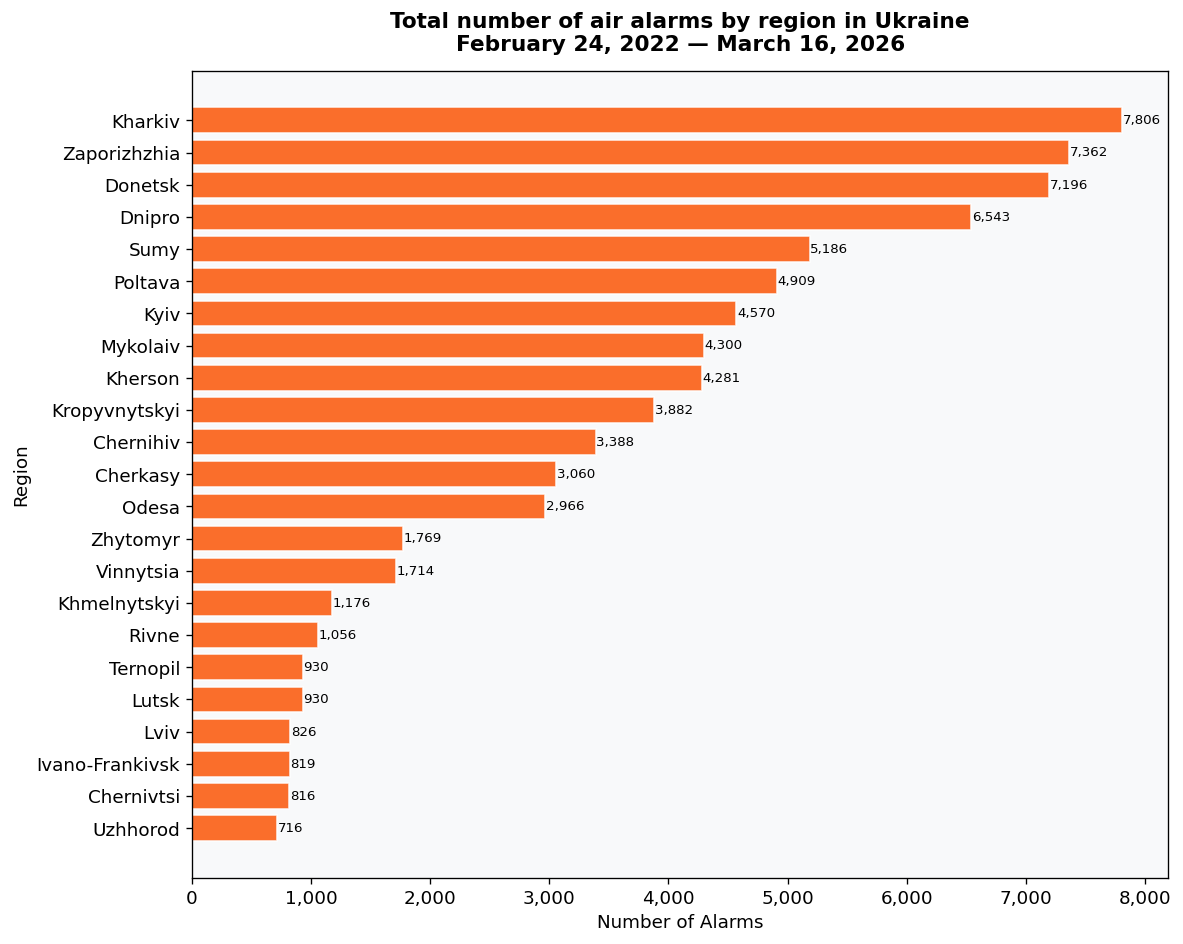

In [26]:
region_counts = df['region'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(region_counts.index, region_counts.values,
               color=MY_PALETTE['main_red'], edgecolor='white', alpha=0.85)
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=8)

ax.set_xlabel('Number of Alarms')
ax.set_ylabel('Region')
ax.set_title('Total number of air alarms by region in Ukraine\n'
             'February 24, 2022 — March 16, 2026', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=False)  
ax.grid(axis='y', visible=False)  
plt.tight_layout()
plt.show()

The top 5 regions by alarm count are Kharkiv (7806), Zaporizhzhia (7362), Donetsk (7196), Dnipro (6543), Sumy (5186)  — all either front-line or exposed to long-range missile strikes. Western regions (Lviv, Zakarpattia) show significantly fewer alarms.

### 4.2 How did alarm frequency change year by year?

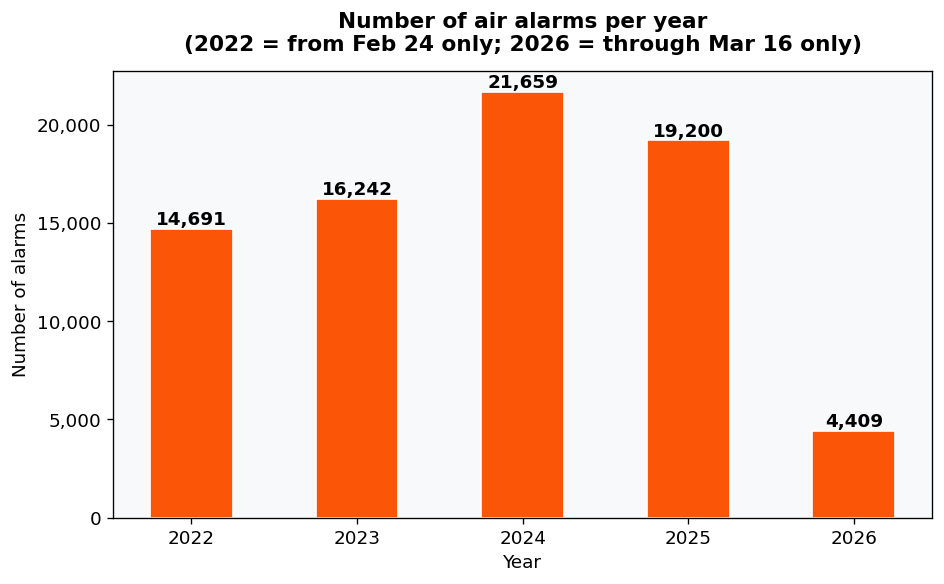

In [27]:
yearly = df['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(yearly.index.astype(str), yearly.values,
              color=MY_PALETTE['main_red'], edgecolor='white', width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(yearly)*0.01,
            f'{int(bar.get_height()):,}', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Year')
ax.set_ylabel('Number of alarms')
ax.set_title('Number of air alarms per year\n'
             '(2022 = from Feb 24 only; 2026 = through Mar 16 only)', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=False)  
ax.grid(axis='y', visible=False)  
plt.tight_layout()
plt.show()

Note that 2022 counts only from February 24; 2026 only through March 16, so direct year-to-year comparison requires normalisation. Despite this, the data clearly shows how alarm activity evolved across three full years of the full-scale war.

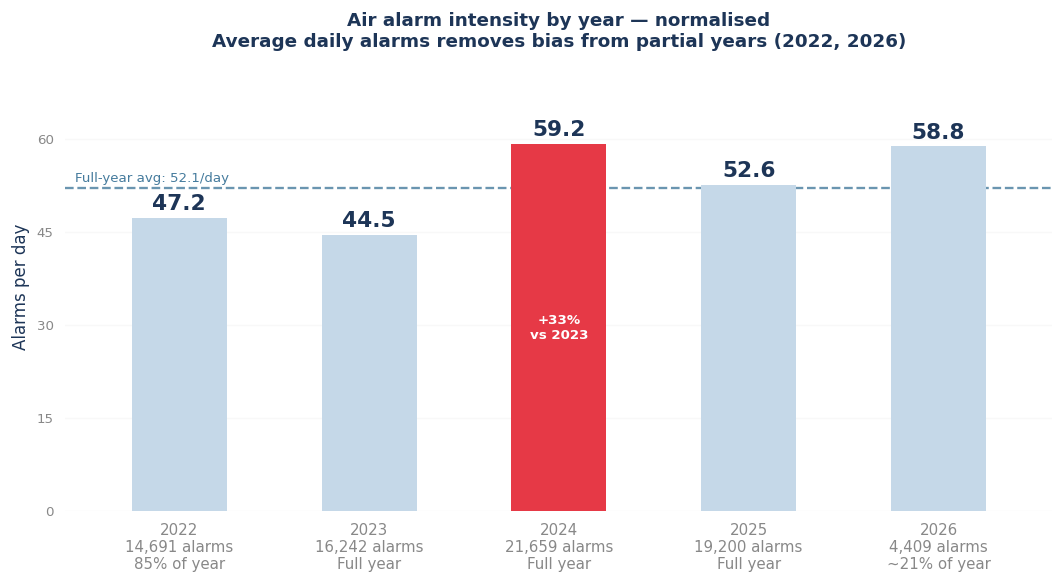

In [28]:
year_stats = df.groupby('year').agg(
    total=('start','count'), first=('start','min'), last=('start','max')
).reset_index()
year_stats['days']    = (year_stats['last'] - year_stats['first']).dt.days + 1
year_stats['per_day'] = year_stats['total'] / year_stats['days']

years   = year_stats['year'].astype(str).tolist()
per_day = year_stats['per_day'].values
totals  = year_stats['total'].values
notes = ['85% of year', 'Full year', 'Full year', 'Full year', '~21% of year']

MUTED='#C5D8E8'; RED='#E63946'; NAVY='#1D3557'; BLUE='#457B9D'; GREY='#888888'

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.set_facecolor('white')

bars = ax.bar(range(len(years)), per_day,
              color=[MUTED, MUTED, RED, MUTED, MUTED],
              edgecolor='none', width=0.5, zorder=3)

for bar, val in zip(bars, per_day):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.6,
            f'{val:.1f}', ha='center', va='bottom',
            fontsize=13, fontweight='bold', color=NAVY)

pct = (per_day[2]-per_day[1])/per_day[1]*100
ax.text(bars[2].get_x()+bars[2].get_width()/2, per_day[2]*0.5,
        f'+{pct:.0f}%\nvs 2023',  
        ha='center', va='center',
        fontsize=8, color='white', fontweight='bold')

full_year_mask = year_stats['days'] >= 360
full_mean = year_stats.loc[full_year_mask, 'per_day'].mean()
ax.axhline(full_mean, color=BLUE, linestyle='--', linewidth=1.4, alpha=0.8, zorder=2)
ax.text(0.01, full_mean+0.5, f'Full-year avg: {full_mean:.1f}/day',
        color=BLUE, fontsize=8, va='bottom', ha='left',
        transform=ax.get_yaxis_transform())

x_labels = [f'{y}\n{t:,} alarms\n{n}' for y,t,n in zip(years,totals,notes)]
ax.set_xticks(range(len(years)))
ax.set_xticklabels(x_labels, fontsize=9, color=GREY)

ax.set_xlim(-0.6, len(years) - 0.4)
ax.set_ylim(0, max(per_day)*1.22)
ax.set_ylabel('Alarms per day', fontsize=10, color=NAVY)
ax.set_title('Air alarm intensity by year — normalised\n'
             'Average daily alarms removes bias from partial years (2022, 2026)',
             fontsize=11, fontweight='bold', color=NAVY, pad=10)

ax.spines[['top','right','left','bottom']].set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.yaxis.set_tick_params(labelcolor=GREY, labelsize=8)
ax.yaxis.set_major_locator(FixedLocator([0, 15, 30, 45, 60]))
ax.grid(axis='y', color='#EEEEEE', linewidth=0.8, zorder=0)
ax.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

This visualisation shows the disctibution of the air alarms' intensity during every year, the numbers were normalised because the amount of months in 2022 and 2026 are not full.

### 4.3 How is alarm activity distributed across months (time series)?

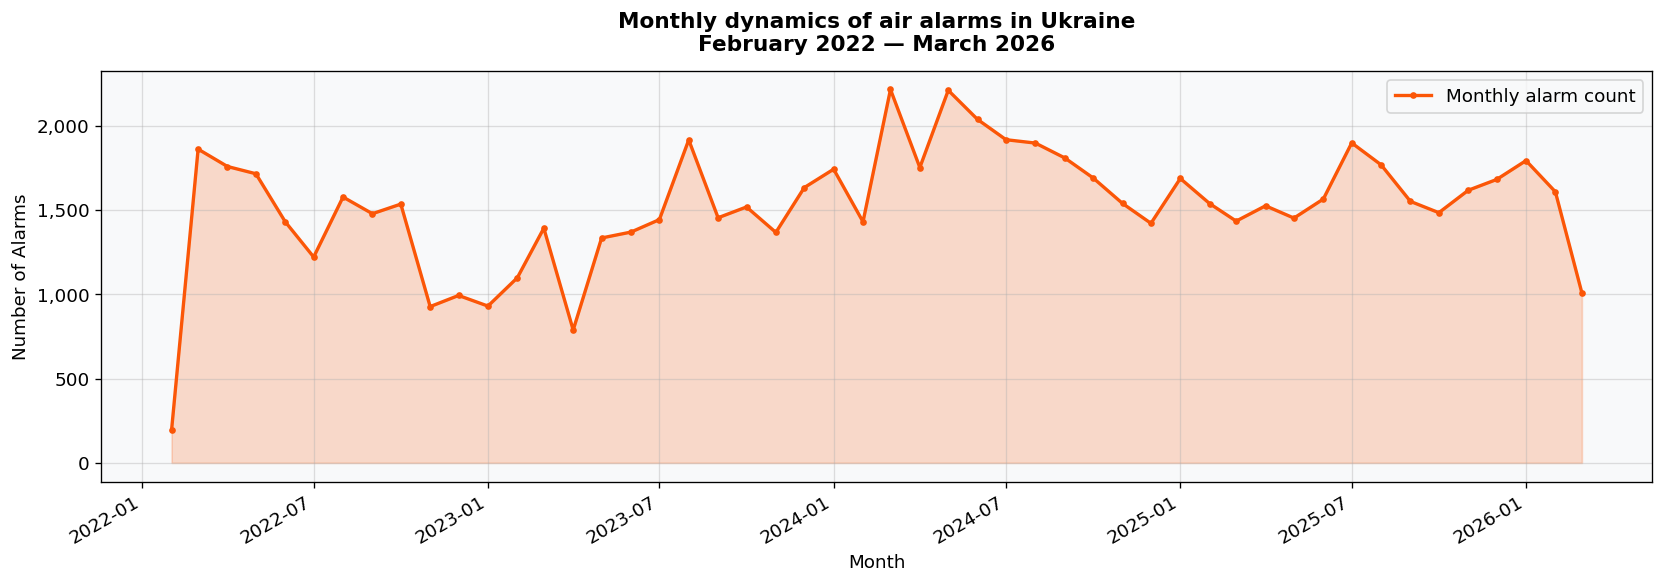

In [29]:
df['month_period'] = df['start'].dt.to_period('M')
monthly = df.groupby('month_period').size().reset_index(name='count')
monthly['month_dt'] = monthly['month_period'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly['month_dt'], monthly['count'], alpha=0.2, color=MY_PALETTE['main_red'])
ax.plot(monthly['month_dt'], monthly['count'],
        color=MY_PALETTE['main_red'], linewidth=2, marker='o', markersize=3,
        label='Monthly alarm count')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Alarms')
ax.set_title('Monthly dynamics of air alarms in Ukraine\n'
             'February 2022 — March 2026', pad=12)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The monthly time series reveals clear peaks and troughs in alarm intensity. Notable spikes correspond to periods of intensified missile and drone attacks. The overall trend indicates shifts in the character of the air campaign over time.

### 4.4 What is the distribution of alarms by day of the week?

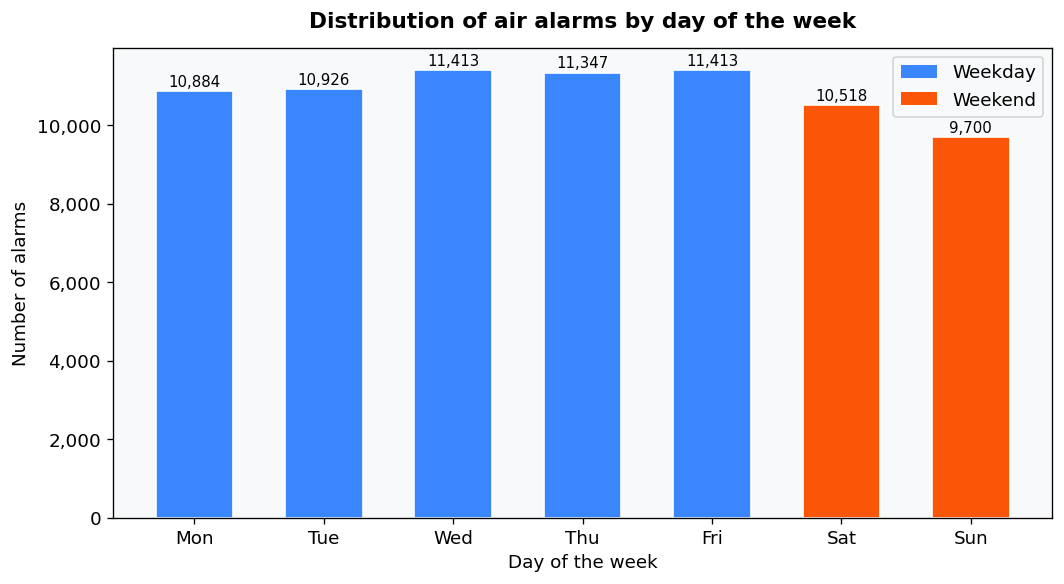

In [30]:
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_counts = df['day_of_week'].value_counts().reindex(range(7), fill_value=0)
colors = [MY_PALETTE['main_red'] if i in [5, 6]
          else MY_PALETTE['accent_blue'] for i in range(7)]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(day_labels, day_counts.values, color=colors, edgecolor='white', width=0.6)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(day_counts)*0.01,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9)

legend_elements = [
    Patch(facecolor=MY_PALETTE['accent_blue'], label='Weekday'),
    Patch(facecolor=MY_PALETTE['main_red'],    label='Weekend')
]
ax.legend(handles=legend_elements, loc='upper right')
ax.set_xlabel('Day of the week')
ax.set_ylabel('Number of alarms')
ax.set_title('Distribution of air alarms by day of the week', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(False)
plt.tight_layout()
plt.show()

The distribution of alarms across days of the week is relatively uniform, suggesting that air attack patterns do not follow a consistent weekly cycle. Any deviation from uniformity may reflect tactical shifts rather than systematic scheduling.

### 4.5 At what hours of the day do alarms most frequently occur?

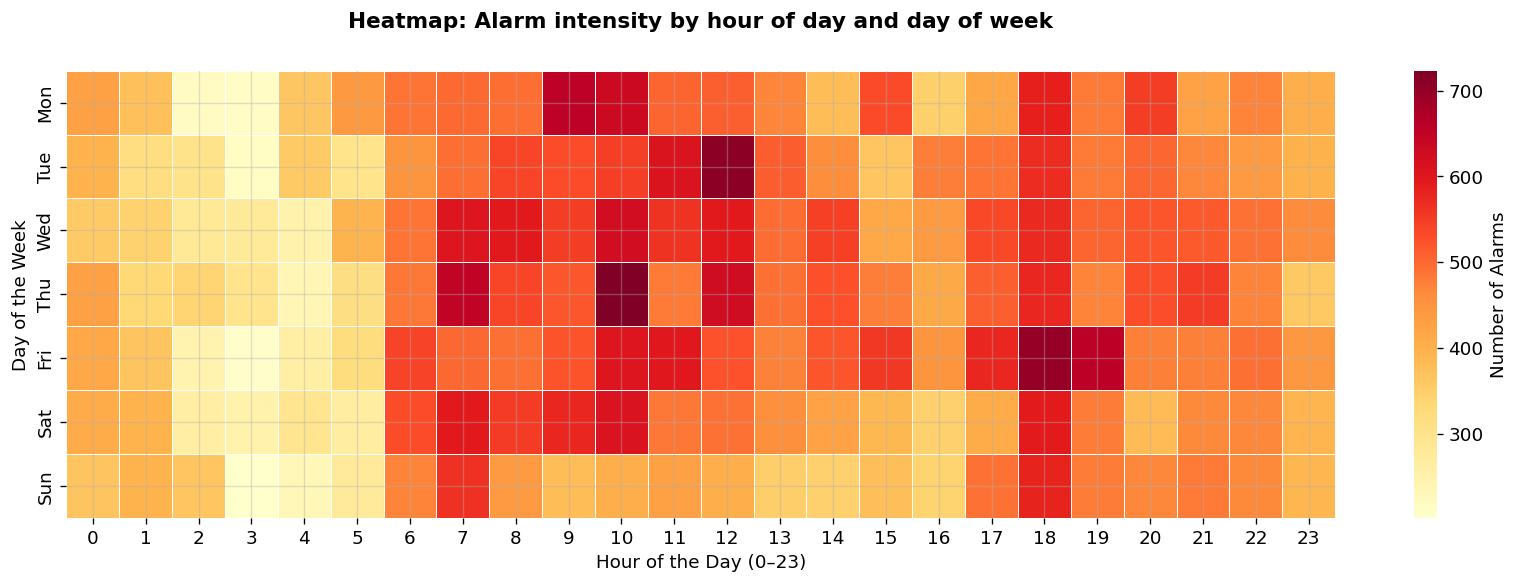

In [31]:
pivot = df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Number of Alarms'})
ax.set_xlabel('Hour of the Day (0–23)')
ax.set_ylabel('Day of the Week')
ax.set_title('Heatmap: Alarm intensity by hour of day and day of week\n', pad=12)
plt.tight_layout()
plt.show()

The heatmap reveals distinct time-of-day patterns in alarm activity. Darker cells indicate hours and days with significantly higher alarm frequency. The data shows two clear activity peaks: the evening hours around 18:00 and the mid-morning hours around 10:00 consistently stand out as the most alarm-intensive periods across all days of the week. This dual-peak pattern suggests a non-random temporal structure in the alarm data, likely reflecting different categories of strike timing throughout the day.

### 4.6 How are alarms distributed across parts of the day?

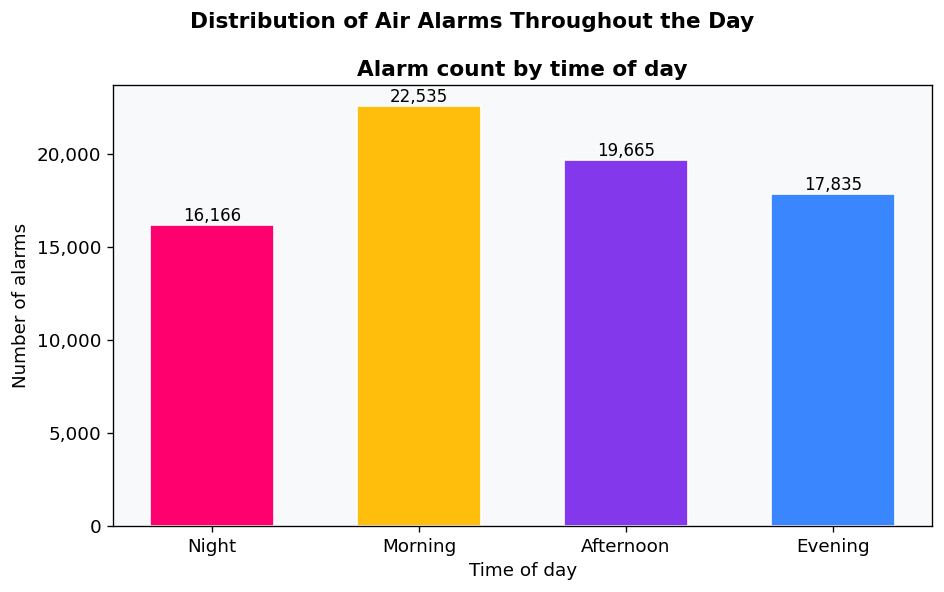

In [32]:
tod_order  = [0, 1, 2, 3]
tod_labels = ['Night', 'Morning', 'Afternoon', 'Evening']
tod_colors = ['#FF006E', '#FFBE0B', '#8338EC', '#3A86FF']
tod_counts = df['time_of_day'].value_counts().reindex(tod_order, fill_value=0)

fig, ax1 = plt.subplots(1, 1, figsize=(8, 5))
ax1.bar(tod_labels, tod_counts.values, color=tod_colors, edgecolor='white', width=0.6)
for i, val in enumerate(tod_counts.values):
    ax1.text(i, val + max(tod_counts)*0.01, f'{val:,}', ha='center', fontsize=10)

ax1.set_xlabel('Time of day')
ax1.set_ylabel('Number of alarms')
ax1.set_title('Alarm count by time of day')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.grid(False)

plt.suptitle('Distribution of Air Alarms Throughout the Day',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Morning hours (6–12) now show the highest alarm frequency, suggesting a shift in attack timing patterns compared to earlier in the war.

---
## 5. Content Analysis

### 5.1 What is the distribution of alarm duration?

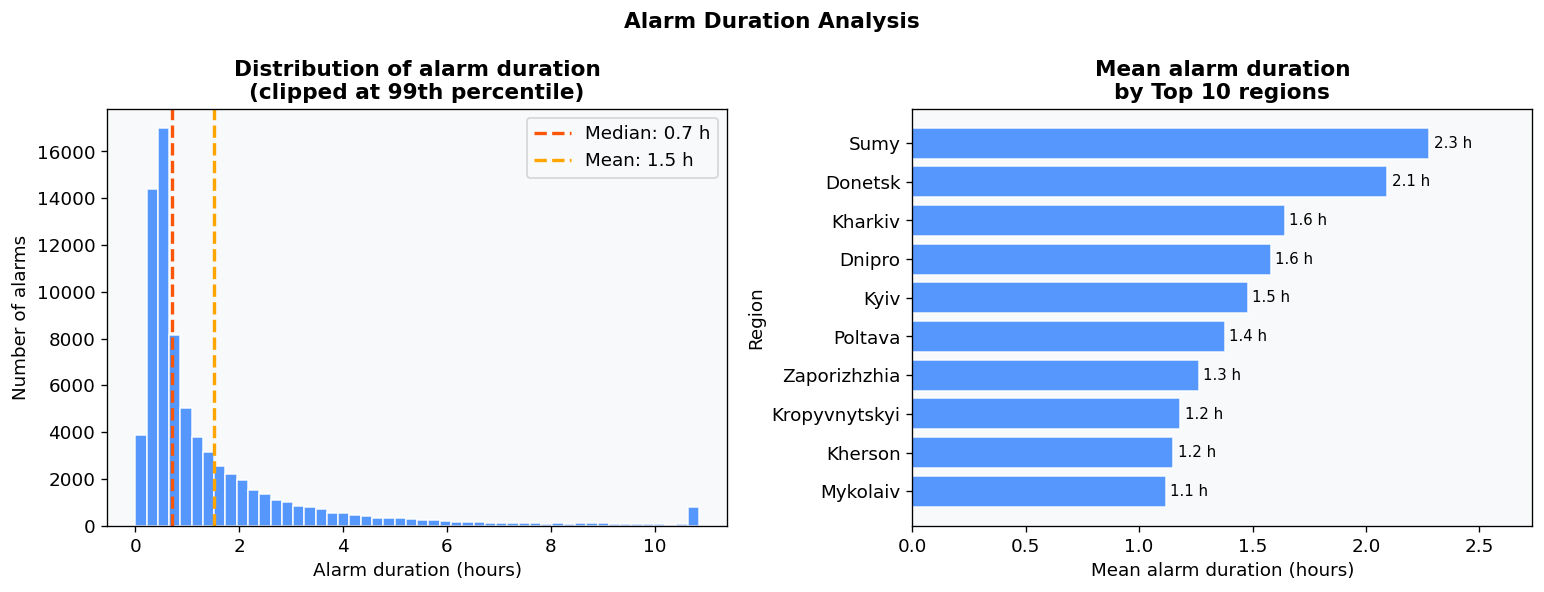

In [33]:
dur = df['duration_hours'].dropna()
dur_clipped = dur.clip(upper=dur.quantile(0.99))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(dur_clipped, bins=50, color=MY_PALETTE['accent_blue'], edgecolor='white', alpha=0.85)
axes[0].axvline(dur.median(), color=MY_PALETTE['main_red'], linestyle='--', linewidth=2,
                label=f'Median: {dur.median():.1f} h')
axes[0].axvline(dur.mean(), color='orange', linestyle='--', linewidth=2,
                label=f'Mean: {dur.mean():.1f} h')
axes[0].set_xlabel('Alarm duration (hours)')
axes[0].set_ylabel('Number of alarms')
axes[0].set_title('Distribution of alarm duration\n(clipped at 99th percentile)')
axes[0].legend()
axes[0].grid(False)

top10 = df['region'].value_counts().head(10).index.tolist()
mean_dur = (df[df['region'].isin(top10)]
            .groupby('region')['duration_hours']
            .mean()
            .sort_values(ascending=True))

bars = axes[1].barh(mean_dur.index, mean_dur.values,
                    color=MY_PALETTE['accent_blue'], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, mean_dur.values):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f} h', va='center', fontsize=9)
axes[1].set_xlim(0, mean_dur.max() * 1.2)  
axes[1].set_xlabel('Mean alarm duration (hours)')
axes[1].set_ylabel('Region')
axes[1].set_title('Mean alarm duration\nby Top 10 regions')
axes[1].grid(False)

plt.suptitle('Alarm Duration Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.show()

Right-skewed distribution of duration: most episodes are short, but there are some long air alarms; frontline regions have a higher median.

### 5.2 What share of alarms covered the entire oblast vs partial area?

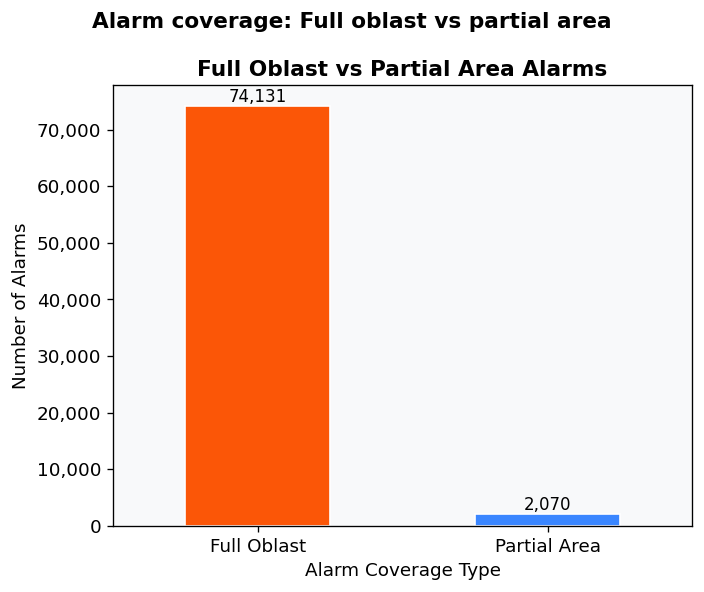

In [34]:
ar_counts = df['all_region'].value_counts().rename({1: 'Full Oblast', 0: 'Partial Area'})

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5))

ar_counts.plot(kind='bar', ax=ax1,
               color=[MY_PALETTE['main_red'], MY_PALETTE['accent_blue']],
               edgecolor='white', width=0.5)
for bar in ax1.patches:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(ar_counts)*0.01,
             f'{int(bar.get_height()):,}', ha='center', fontsize=10)
ax1.set_xlabel('Alarm Coverage Type')
ax1.set_ylabel('Number of Alarms')
ax1.set_title('Full Oblast vs Partial Area Alarms')
ax1.tick_params(axis='x', rotation=0)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.grid(False)

plt.suptitle('Alarm coverage: Full oblast vs partial area',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Over 97% of records in this dataset cover the entire oblast — a result of the merged-alarms preprocessing that unifies district-level alarms to oblast level.

### 5.3 How did alarm dynamics evolve in the top 5 most affected regions?

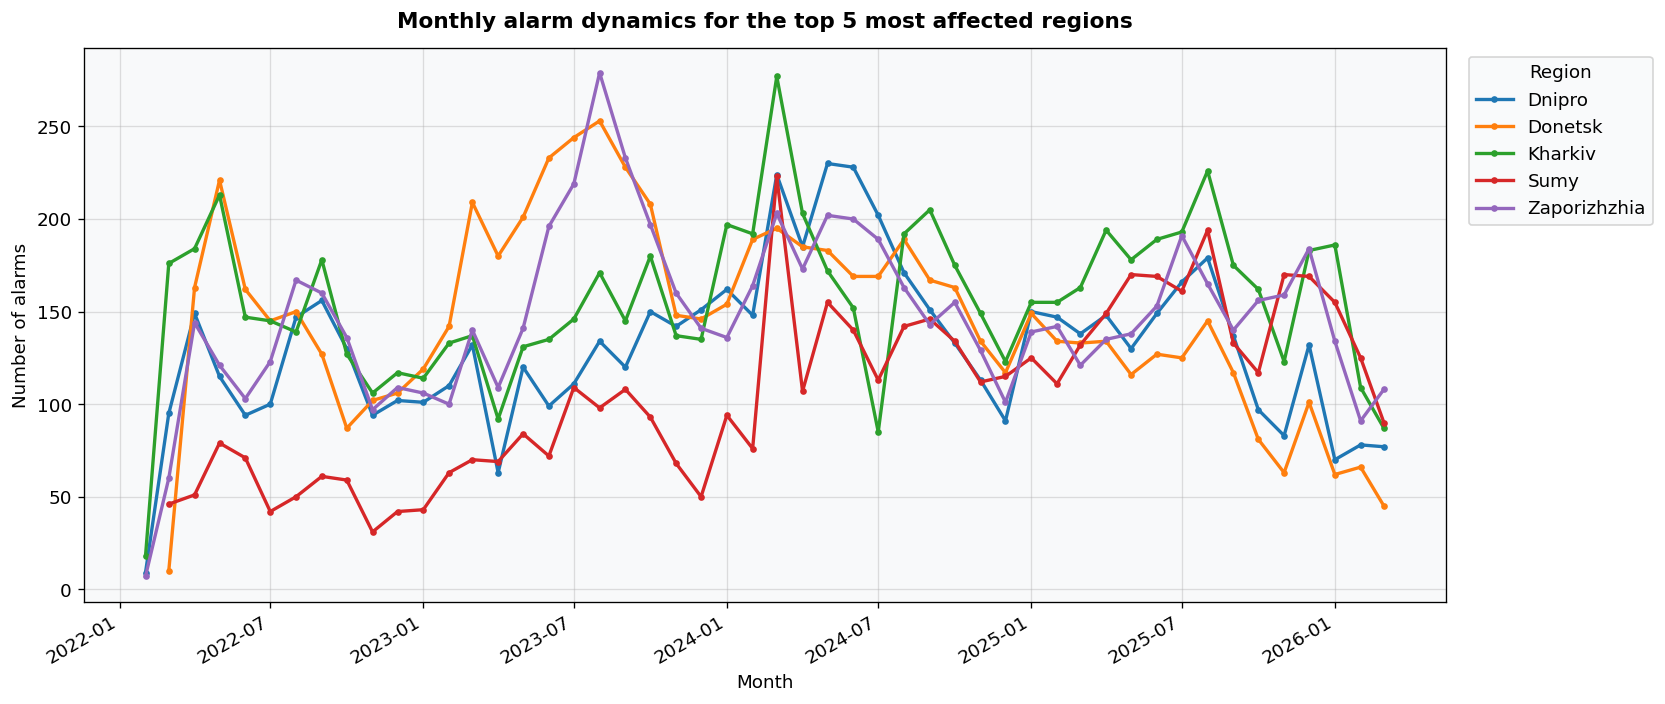

In [35]:
top5 = df['region'].value_counts().head(5).index.tolist()
df_top5 = df[df['region'].isin(top5)].copy()
df_top5['month_period'] = df_top5['start'].dt.to_period('M')
monthly_region = (
    df_top5.groupby(['region','month_period'])
    .size().reset_index(name='count')
)
monthly_region['month_dt'] = monthly_region['month_period'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette('tab10', 5)
for (region, group), color in zip(monthly_region.groupby('region'), palette):
    ax.plot(group['month_dt'], group['count'],
            label=region, color=color, linewidth=2, marker='.')

ax.set_xlabel('Month')
ax.set_ylabel('Number of alarms')
ax.set_title('Monthly alarm dynamics for the top 5 most affected regions', pad=12)
ax.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The peaks in different regions do not coincide in time—the attacks were concentrated in specific regions during different periods.

---
## 6. Creating new dataframe

In this section we are switching from the event-level `df` to the hourly-level `alarms_hourly`. The original `df` contains events with exact start and end times for alarms, but hourly data is required for lags, rolling indicators, and merging with weather data, so it was converted the events into an hourly dataset called `alarms_hourly`.

### 6.1 Creating a dataframe of expanded alarms to hours

Checking there are correct time ranges (seconds was applied to resolve a case like this: end_time = 16:00, but with this second the hour 16 will not be included in range)

In [36]:
df['start_hour'] = df['start'].dt.floor('h')
df['end_hour'] = (df['end'] - pd.Timedelta(seconds=1)).dt.floor('h') 

This code takes a single line from `df` and expands it into a list of times.

In [37]:
def expand_alarm_to_hours(alarm: 'pd.Series') -> 'Optional[pd.DataFrame]':
    
    if pd.isna(alarm['end_hour']) or alarm['end_hour'] < alarm['start_hour']:
        return None
    hourly_timestamps = pd.date_range(
        start = alarm['start_hour'],
        end   = alarm['end_hour'],
        freq  = 'h'
    )
    return pd.DataFrame({
        'datetime' : hourly_timestamps,
        'region'   : alarm['region'],
        'alarm'    : 1
    })


Checking if time range correct.

In [38]:
df[['start', 'end', 'start_hour', 'end_hour']].head(10)

,start,end,start_hour,end_hour
0,2022-02-25 16:54:07+00:00,2022-02-25 19:24:04+00:00,2022-02-25 16:00:00+00:00,2022-02-25 19:00:00+00:00
1,2022-02-26 04:40:07+00:00,2022-02-26 05:34:07+00:00,2022-02-26 04:00:00+00:00,2022-02-26 05:00:00+00:00
2,2022-02-27 17:10:07+00:00,2022-02-27 18:10:07+00:00,2022-02-27 17:00:00+00:00,2022-02-27 18:00:00+00:00
3,2022-02-27 18:11:07+00:00,2022-02-27 20:03:07+00:00,2022-02-27 18:00:00+00:00,2022-02-27 20:00:00+00:00
4,2022-02-27 21:21:07+00:00,2022-02-28 01:00:07+00:00,2022-02-27 21:00:00+00:00,2022-02-28 01:00:00+00:00
5,2022-02-28 05:22:07+00:00,2022-02-28 07:55:04+00:00,2022-02-28 05:00:00+00:00,2022-02-28 07:00:00+00:00
6,2022-02-28 10:38:07+00:00,2022-02-28 11:02:04+00:00,2022-02-28 10:00:00+00:00,2022-02-28 11:00:00+00:00
7,2022-03-01 08:26:07+00:00,2022-03-01 09:00:06+00:00,2022-03-01 08:00:00+00:00,2022-03-01 09:00:00+00:00
8,2022-03-01 10:40:07+00:00,2022-03-01 11:00:06+00:00,2022-03-01 10:00:00+00:00,2022-03-01 11:00:00+00:00
9,2022-03-01 12:15:07+00:00,2022-03-01 16:30:07+00:00,2022-03-01 12:00:00+00:00,2022-03-01 16:00:00+00:00


### Creating alarms_hourly

Unpacks each alarm from df into hourly rows and puts them into a single dataframe called alarms_hourly:

In [39]:
alarms_hourly = pd.concat(
    df.apply(expand_alarm_to_hours, axis=1).dropna().tolist(),
    ignore_index=True
)

print(f'alarms_hourly created: {alarms_hourly.shape}')

alarms_hourly created: (191800, 3)


Removing duplicated hours if two alarms overlapped — one row per (region, hour):


In [40]:
alarms_hourly = (
    alarms_hourly
    .groupby(['region', 'datetime'], as_index=False)['alarm']
    .max()
)

 Creting separate dataframe for active_per_hour. It counts the number of regions across Ukraine for each hour (an aggregation across all regions at the same time). 

In [41]:
active_per_hour = (
    alarms_hourly[alarms_hourly['alarm'] == 1]
    .groupby('datetime')['region']
    .nunique()
    .reset_index()
    .rename(columns={'region': 'active_regions_count'})
)

### Hourly Grid 
This code builds the complete empty timeline before filling it with alarm data with the combintation of region × hour. 

In [42]:
all_regions = alarms_hourly['region'].unique()
full_range = pd.date_range(
    start=alarms_hourly['datetime'].min(),
    end=alarms_hourly['datetime'].max(),
    freq='h',
    tz='UTC'
)
full_grid = pd.MultiIndex.from_product(
    [all_regions, full_range], names=['region', 'datetime']
)

### Turning it into the real dataframe and attaching all of the data

In [43]:
alarms_hourly = (
    pd.DataFrame(index=full_grid)
    .reset_index()
    .merge(alarms_hourly, on=['region', 'datetime'], how='left') #attaches the alarm data, because it's a left join, every row from the grid is kept
)
alarms_hourly['alarm'] = alarms_hourly['alarm'].fillna(0).astype(int)
print(f'Shape after full grid: {alarms_hourly.shape}')
print(f'active_per_hour shape: {active_per_hour.shape}')

Shape after full grid: (818087, 3)
active_per_hour shape: (29147, 2)


### 6.2 Adding lags 
(temporal memory of previous alarms for machine) of 1,3,6,24 hours:

In [44]:
alarms_hourly['alarm_lag_1h']  = alarms_hourly.groupby('region')['alarm'].shift(1).fillna(0).astype(int)
alarms_hourly['alarm_lag_3h']  = alarms_hourly.groupby('region')['alarm'].shift(3).fillna(0).astype(int)
alarms_hourly['alarm_lag_6h']  = alarms_hourly.groupby('region')['alarm'].shift(6).fillna(0).astype(int)
alarms_hourly['alarm_lag_24h'] = alarms_hourly.groupby('region')['alarm'].shift(24).fillna(0).astype(int)

print('Lag features added')

Lag features added


In [45]:
alarms_hourly[
    (alarms_hourly['region'] == 'Kharkiv') & 
    (alarms_hourly['datetime'] >= '2023-02-20') & 
    (alarms_hourly['datetime'] <= '2023-02-21')
][
    ['region', 'datetime', 'alarm',
     'alarm_lag_1h', 'alarm_lag_3h',
     'alarm_lag_6h', 'alarm_lag_24h']
]

,region,datetime,alarm,alarm_lag_1h,alarm_lag_3h,alarm_lag_6h,alarm_lag_24h
222073,Kharkiv,2023-02-20 00:00:00+00:00,0,1,0,0,0
222074,Kharkiv,2023-02-20 01:00:00+00:00,0,0,0,0,0
222075,Kharkiv,2023-02-20 02:00:00+00:00,0,0,1,0,0
222076,Kharkiv,2023-02-20 03:00:00+00:00,0,0,0,0,0
222077,Kharkiv,2023-02-20 04:00:00+00:00,0,0,0,0,1
222078,Kharkiv,2023-02-20 05:00:00+00:00,0,0,0,1,1
222079,Kharkiv,2023-02-20 06:00:00+00:00,0,0,0,0,1
222080,Kharkiv,2023-02-20 07:00:00+00:00,0,0,0,0,1
222081,Kharkiv,2023-02-20 08:00:00+00:00,0,0,0,0,1
222082,Kharkiv,2023-02-20 09:00:00+00:00,1,0,0,0,1


### 6.3 Visualisation: How many regions were simultaneously under alarm over time?

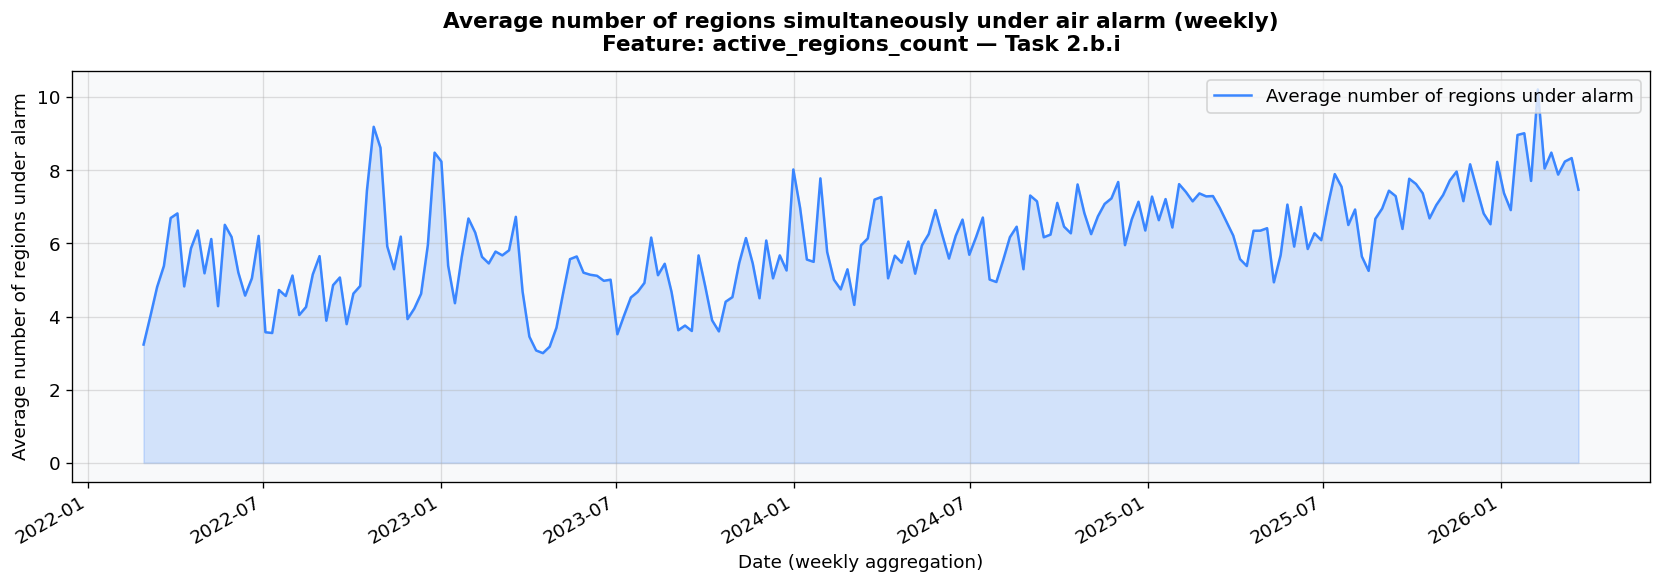

In [46]:
fig, ax = plt.subplots(figsize=(14, 5))

active_weekly = (
    active_per_hour
    .set_index('datetime')          
    ['active_regions_count']
    .resample('W').mean()
)

ax.fill_between(active_weekly.index, active_weekly.values,
                alpha=0.2, color=MY_PALETTE['accent_blue'])
ax.plot(active_weekly.index, active_weekly.values,
        color=MY_PALETTE['accent_blue'], linewidth=1.5,
        label='Average number of regions under alarm')

ax.set_xlabel('Date (weekly aggregation)')
ax.set_ylabel('Average number of regions under alarm')
ax.set_title('Average number of regions simultaneously under air alarm (weekly)\n'
             'Feature: active_regions_count — Task 2.b.i', pad=12)
ax.legend(loc='upper right')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

This chart visualises the engineered feature `active_regions_count` — the average number of Ukrainian regions simultaneously under alarm in any given week. Peaks in this chart suggest mass missile or drone attack waves that triggered alarms across many oblasts at once, while lower values indicate more localised incidents.

### 6.4 Distribution of the alarm_events_last_24h feature by region

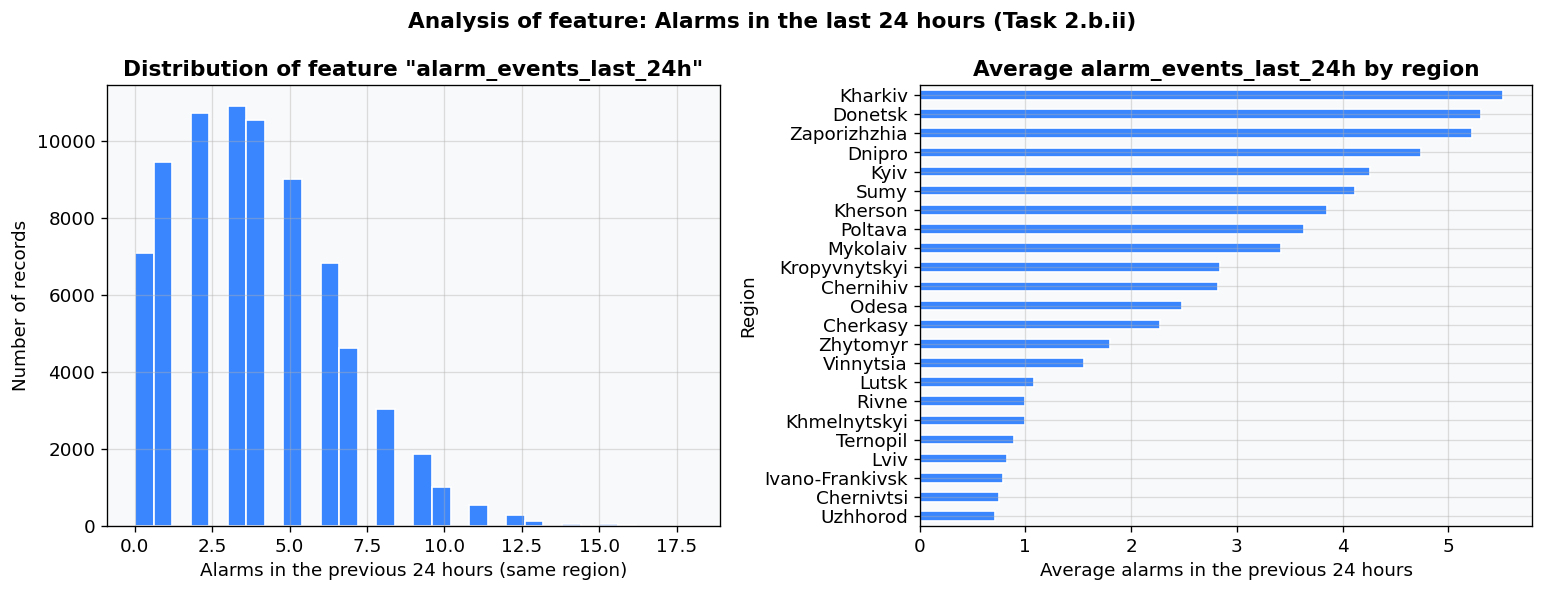

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['alarm_events_last_24h'].dropna(), bins=30,
             color=MY_PALETTE['accent_blue'], edgecolor='white')
axes[0].set_xlabel('Alarms in the previous 24 hours (same region)')
axes[0].set_ylabel('Number of records')
axes[0].set_title('Distribution of feature "alarm_events_last_24h"')

avg_24h = df.groupby('region')['alarm_events_last_24h'].mean().sort_values(ascending=True)
avg_24h.plot(kind='barh', ax=axes[1],
             color=MY_PALETTE['accent_blue'], edgecolor='white')
axes[1].set_xlabel('Average alarms in the previous 24 hours')
axes[1].set_ylabel('Region')
axes[1].set_title('Average alarm_events_last_24h by region')

plt.suptitle('Analysis of feature: Alarms in the last 24 hours (Task 2.b.ii)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Most air alarms events occur when there is low pre air alarm activity in the region; regions near the front zone have a consistently higher rolling rate. *rolling rate is a rate of what was the situation 'earlier' (air alarms, duration)

# 7.1 Mergings of all dataframes in alarms_hourly

active_regions_count — how many regions total across Ukraine were under alarm at the same hour (indicating a large-scale attack)



In [48]:
alarms_hourly = alarms_hourly.merge( 
    active_per_hour, #Takes the already-built 608k grid and joins how many regions were simultaneously under alarm at each hour
    on='datetime',
    how='left'
)
alarms_hourly['active_regions_count'] = alarms_hourly['active_regions_count'].fillna(0).astype(int)

'quiet' hours have no entries in active_per_hour; after the left join, there are NaN values there -> replaced them with 0

#### alarm_events_last_24h

Creating dataframe events_per_hour with region, start_hour, alarm_events_last_24h. `alarm_events_last_24h` lives in `df` (event-level), but we need this column in `alarms_hourly` (hour-level). This code bridges a feature that was computed on event-level data onto the hourly grid (hourly-level).

In [49]:
alarm_starts = (
    df.groupby(['region', 'start_hour'])
    .size()
    .reset_index(name='alarm_start')
    .rename(columns={'start_hour': 'datetime'})
)

alarms_hourly = alarms_hourly.merge(alarm_starts, on=['region', 'datetime'], how='left')
alarms_hourly['alarm_start'] = alarms_hourly['alarm_start'].fillna(0).astype(int)

alarms_hourly = alarms_hourly.sort_values(['region', 'datetime']).reset_index(drop=True)
alarms_hourly.index = pd.DatetimeIndex(alarms_hourly['datetime'])

alarms_hourly['alarm_events_last_24h'] = (
    alarms_hourly.groupby('region')['alarm_start']
    .transform(lambda x: x.rolling('24h', closed='left').sum())
).values

alarms_hourly = alarms_hourly.reset_index(drop=True)
alarms_hourly['alarm_events_last_24h'] = alarms_hourly['alarm_events_last_24h'].fillna(0).astype(int)
alarms_hourly = alarms_hourly.drop(columns=['alarm_start'])

#### alarm_hours_last_24
Counts how many hourly slots had alarm = 1 in last 24h (alarmed *hours* in the past 24h).

Different from alarm_events_last_24h in df which counts alarm *starts*.

In [50]:
alarms_hourly = alarms_hourly.sort_values(['region', 'datetime']).reset_index(drop=True)
alarms_hourly.index = pd.DatetimeIndex(alarms_hourly['datetime'])
alarms_hourly['alarm_hours_last_24h'] = (
    alarms_hourly.groupby('region')['alarm']
    .transform(lambda x: x.rolling('24h', closed='left').sum())
).values
alarms_hourly = alarms_hourly.reset_index(drop=True)
alarms_hourly['alarm_hours_last_24h'] = alarms_hourly['alarm_hours_last_24h'].fillna(0).astype(int)


In [51]:
sample_region = 'Kyiv'

#full grid (all hours)
print("full_grid:")
grid_sample = alarms_hourly[alarms_hourly['region'] == sample_region][['region', 'datetime']].head(4)
print(grid_sample.to_string(index=False))

#active alarms only (before join)
print("\nalarms_hourly (active only):")
active_sample = alarms_hourly[
    (alarms_hourly['region'] == sample_region) &
    (alarms_hourly['alarm'] == 1)
][['region', 'datetime', 'alarm']].head(1)
print(active_sample.to_string(index=False))

#after left join + fillna — showing 0s and 1s around active hour
print("\nAfter left join + fillna(0):")
target_dt = active_sample['datetime'].values[0]
target_dt = pd.Timestamp(target_dt).tz_localize('UTC') if pd.Timestamp(target_dt).tzinfo is None else pd.Timestamp(target_dt)

start_dt = target_dt - pd.Timedelta(hours=2)
end_dt   = target_dt + pd.Timedelta(hours=1)

final_sample = alarms_hourly[
    (alarms_hourly['region'] == sample_region) &
    (alarms_hourly['datetime'] >= start_dt) &
    (alarms_hourly['datetime'] <= end_dt)
][['region', 'datetime', 'alarm']]
print(final_sample.to_string(index=False))

full_grid:
region                  datetime
  Kyiv 2022-02-24 05:00:00+00:00
  Kyiv 2022-02-24 06:00:00+00:00
  Kyiv 2022-02-24 07:00:00+00:00
  Kyiv 2022-02-24 08:00:00+00:00

alarms_hourly (active only):
region                  datetime  alarm
  Kyiv 2022-02-25 05:00:00+00:00      1

After left join + fillna(0):
region                  datetime  alarm
  Kyiv 2022-02-25 03:00:00+00:00      0
  Kyiv 2022-02-25 04:00:00+00:00      0
  Kyiv 2022-02-25 05:00:00+00:00      1
  Kyiv 2022-02-25 06:00:00+00:00      0


# 7.2 Creating final alarms_hourly.csv

All crucial columns are included in the final dataset.

In [52]:
alarms_hourly = alarms_hourly[['region', 'datetime', 'alarm',
                                'active_regions_count',
                                'alarm_hours_last_24h',
                                'alarm_events_last_24h',
                                'alarm_lag_1h', 'alarm_lag_3h',
                                'alarm_lag_6h', 'alarm_lag_24h']]

In [53]:

alarms_hourly.to_csv('alarms_hourly.csv', index=False)
print(alarms_hourly.columns.tolist())
print(f'Shape: {alarms_hourly.shape}')
alarms_hourly.head()

['region', 'datetime', 'alarm', 'active_regions_count', 'alarm_hours_last_24h', 'alarm_events_last_24h', 'alarm_lag_1h', 'alarm_lag_3h', 'alarm_lag_6h', 'alarm_lag_24h']
Shape: (818087, 10)


,region,datetime,alarm,active_regions_count,alarm_hours_last_24h,alarm_events_last_24h,alarm_lag_1h,alarm_lag_3h,alarm_lag_6h,alarm_lag_24h
0,Cherkasy,2022-02-24 05:00:00+00:00,0,1,0,0,0,0,0,0
1,Cherkasy,2022-02-24 06:00:00+00:00,0,1,0,0,0,0,0,0
2,Cherkasy,2022-02-24 07:00:00+00:00,0,1,0,0,0,0,0,0
3,Cherkasy,2022-02-24 08:00:00+00:00,0,0,0,0,0,0,0,0
4,Cherkasy,2022-02-24 09:00:00+00:00,0,0,0,0,0,0,0,0


Sanity check: ensuring that hourly grid is complete. Each region should have one row per hour in the full time range

In [54]:
expected_hours = pd.date_range(
    start=alarms_hourly['datetime'].min(),
    end=alarms_hourly['datetime'].max(),
    freq='h',
    tz='UTC'
)

expected = alarms_hourly['region'].nunique() * len(expected_hours)

print(f'Expected hours: {len(expected_hours):,}')
print(f'Expected rows:  {expected:,}')
print(f'Actual rows:    {len(alarms_hourly):,}')
print(f'Difference:     {len(alarms_hourly) - expected:,}')

Expected hours: 35,569
Expected rows:  818,087
Actual rows:    818,087
Difference:     0
